In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PRICE_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "prices"

PRICE_DATA_DIR

WindowsPath('c:/Users/carlj/Documents/ai-trading-lab/data/raw/prices')

In [3]:
csv_files = list(PRICE_DATA_DIR.glob("*.csv"))

csv_files

[WindowsPath('c:/Users/carlj/Documents/ai-trading-lab/data/raw/prices/AAPL.csv'),
 WindowsPath('c:/Users/carlj/Documents/ai-trading-lab/data/raw/prices/MSFT.csv'),
 WindowsPath('c:/Users/carlj/Documents/ai-trading-lab/data/raw/prices/NVDA.csv'),
 WindowsPath('c:/Users/carlj/Documents/ai-trading-lab/data/raw/prices/TSLA.csv')]

In [4]:
symbol = "AAPL"

csv_path = PRICE_DATA_DIR / f"{symbol}.csv"

price_data = pd.read_csv(
    csv_path,
    parse_dates=["Date"],
    index_col="Date",
)

price_data.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2024-01-02,187.149994,188.440002,183.889999,185.639999,183.562210,82488700,0.0,0.0
2024-01-03,184.220001,185.880005,183.429993,184.250000,182.187744,58414500,0.0,0.0
2024-01-04,182.149994,183.089996,180.880005,181.910004,179.873932,71983600,0.0,0.0
2024-01-05,181.990005,182.759995,180.169998,181.179993,179.152130,62379700,0.0,0.0
2024-01-08,182.089996,185.600006,181.500000,185.559998,183.483078,59144500,0.0,0.0


In [5]:
price_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 61 entries, 2024-01-02 to 2024-03-28
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          61 non-null     float64
 1   High          61 non-null     float64
 2   Low           61 non-null     float64
 3   Close         61 non-null     float64
 4   Adj Close     61 non-null     float64
 5   Volume        61 non-null     int64  
 6   Dividends     61 non-null     float64
 7   Stock Splits  61 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 4.3 KB


In [6]:
price_data.describe()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,61.000000,61.000000,61.000000,61.000000,61.000000,6.100000e+01,61.000000,61.0
mean,181.781639,183.216885,180.228852,181.830327,179.919720,6.200321e+07,0.003934,0.0
std,7.425722,7.279020,7.333935,7.413214,7.253545,1.924904e+07,0.030729,0.0
min,169.000000,170.729996,168.490005,169.000000,167.321671,4.047780e+07,0.000000,0.0
25%,175.570007,176.899994,173.029999,173.720001,171.994781,4.912840e+07,0.000000,0.0
50%,182.240005,184.490005,180.929993,182.679993,180.816315,5.652950e+07,0.000000,0.0
75%,186.860001,188.440002,185.190002,186.860001,184.768555,6.966880e+07,0.000000,0.0
max,195.419998,196.380005,194.339996,195.179993,192.995407,1.366826e+08,0.240000,0.0


In [7]:
price_data.isna().sum()

Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

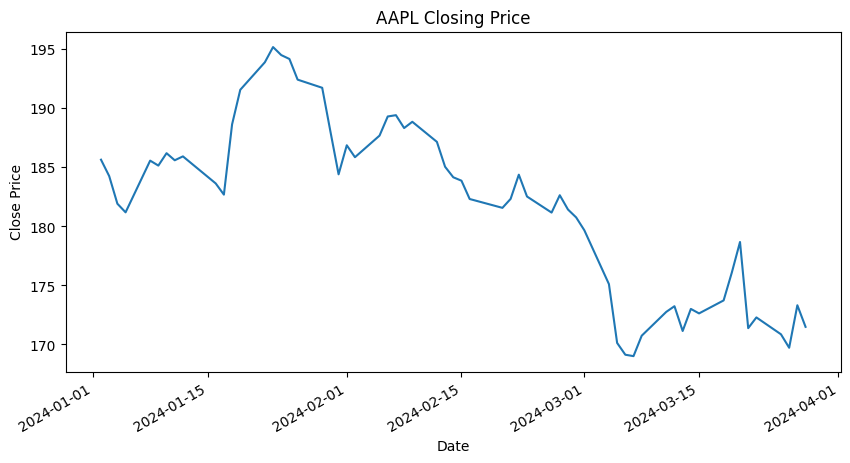

In [8]:
price_data["Close"].plot(
    title=f"{symbol} Closing Price",
    figsize=(10, 5),
)

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [9]:
price_data["daily_return"] = price_data["Close"].pct_change()

price_data[["Close", "daily_return"]].head(10)

,Close,daily_return
Date,,
2024-01-02,185.639999,NaN
2024-01-03,184.250000,-0.007488
2024-01-04,181.910004,-0.012700
2024-01-05,181.179993,-0.004013
2024-01-08,185.559998,0.024175
2024-01-09,185.139999,-0.002263
2024-01-10,186.190002,0.005671
2024-01-11,185.589996,-0.003223
2024-01-12,185.919998,0.001778


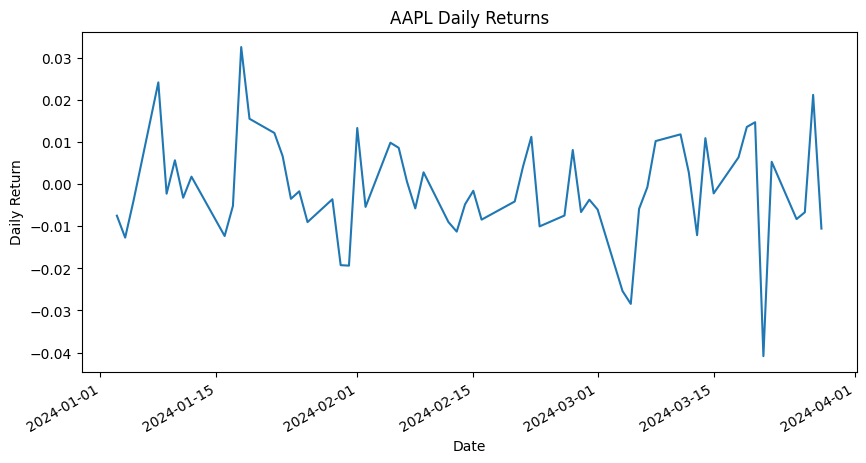

In [10]:
price_data["daily_return"].plot(
    title=f"{symbol} Daily Returns",
    figsize=(10, 5),
)

plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

In [11]:
price_data["daily_return"].describe()

count    60.000000
mean     -0.001244
std       0.012575
min      -0.040857
25%      -0.007691
50%      -0.003353
75%       0.007019
max       0.032571
Name: daily_return, dtype: float64